# 03b — Simpler Cloud Segmentation Models

## Executive Summary
Comparison of two lighter alternatives to the ResNet-34 U-Net (notebook 03):

**Model A — MobileNetV2 U-Net**
Same `segmentation-models-pytorch` U-Net framework, encoder swapped to MobileNetV2.
~4× fewer parameters (3.4M vs 24M), ~3× faster training/inference on CPU.
Still pretrained on ImageNet — fine-tuning from good initialisation.

**Model B — Random Forest pixel classifier**
No neural network. Per-pixel features: R/B ratio, R/G ratio, HSV (H, S, V),
zenith angle, local patch mean/std (5×5). Trains in seconds on CPU.
Fully interpretable — feature importances reveal which signals drive classification.

**Both models use the same train/val/test split as notebook 03** (random_state=42)
so results are directly comparable.

**Pipeline:**
1. Build dataset and split (identical to notebook 03)
2. Train and evaluate MobileNetV2 U-Net
3. Train and evaluate Random Forest classifier
4. Compare all three models (ResNet-34, MobileNetV2, RF) on the Warsaw test set
5. Run the best simpler model on all pilot images

In [1]:
import sys, logging
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s | %(name)s | %(message)s',
                    datefmt='%H:%M:%S')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from skycamera.config import CX, CY, R, CSV_DIR, PLOTS_DIR, MASKS_PRED_DIR, MODEL_DIR, FULL_RAW_DIR, CF_MAX_ZENITH_DEG
from skycamera.io import load_image, build_combined_dataset, build_image_index
from skycamera.preprocessing import (
    build_circular_mask, build_zenith_weight_map, weighted_cf, _infer_dome_params,
)
from skycamera.labelling import load_existing_mask, LABEL_CLOUD, LABEL_SKY

RAW_ROOT     = FULL_RAW_DIR   # data/full_raw/ — full year, thinned to 30-min intervals
ACS_ROOT     = Path('D:/MOJE/DATA_SCIENCE/SKYCAMERA/ACS_WSI-v1.0.0')
MANUAL_MASKS = Path('..') / 'data' / 'masks_manual'
INDEX_CSV    = CSV_DIR / 'image_index.csv'

for d in [CSV_DIR, PLOTS_DIR, MASKS_PRED_DIR, MODEL_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

# Dome mask and zenith weight map at native resolution
_sample_path = next(FULL_RAW_DIR.rglob('*.jpg'))
_s = load_image(_sample_path)
dome_mask      = build_circular_mask(_s.shape[0], _s.shape[1], CX, CY, R)
zenith_weights = build_zenith_weight_map(_s.shape[0], _s.shape[1], CX, CY, R, CF_MAX_ZENITH_DEG)
print(f'Setup complete  |  dome pixels: {dome_mask.sum():,}  |  CF max zenith: {CF_MAX_ZENITH_DEG}°')
print(f'Image root: {RAW_ROOT}')

Setup complete  |  dome pixels: 2,762,359  |  CF max zenith: 70.0°
Image root: D:\MOJE\DATA_SCIENCE\SKYCAMERA\skycamera\data\full_raw


## 1. Build combined dataset — same split as notebook 03

In [2]:
df_all    = build_combined_dataset(ACS_ROOT, MANUAL_MASKS)
df_acs    = df_all[df_all['source'] == 'acs_wsi'].copy()
df_manual = df_all[df_all['source'] == 'manual'].copy()

MIN_MANUAL_FOR_SPLIT = 5
if len(df_manual) >= MIN_MANUAL_FOR_SPLIT:
    df_manual_trainval, df_test = train_test_split(
        df_manual, test_size=0.20, random_state=42)
    df_manual_train, df_manual_val = train_test_split(
        df_manual_trainval, test_size=0.25, random_state=42)
else:
    df_manual_train = df_manual
    df_manual_val   = df_manual.iloc[0:0]
    df_test         = df_manual.iloc[0:0]

df_acs_train, df_acs_val = train_test_split(
    df_acs, test_size=0.20, stratify=df_acs['cf_level'], random_state=42)

df_train = pd.concat([df_acs_train, df_manual_train], ignore_index=True)
df_val   = pd.concat([df_acs_val,   df_manual_val],   ignore_index=True)

print(f'Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}')

Combined dataset summary
  ACS_WSI pairs  : 77
  Manual pairs   : 627
  Total          : 704

  CF measured — mean=0.571  std=0.432  min=0.000  max=1.000

  Class balance (by measured CF):
    Clear   (<0.2) : 229  (32.5%)
    Partial (0.2–0.8): 144  (20.5%)
    Cloudy  (>0.8) : 331  (47.0%)
Train: 436  Val: 142  Test: 126


## 2. Model A — MobileNetV2 U-Net

Identical training setup to notebook 03 (BCE loss, Adam, weighted per-pixel loss,
early stopping) with encoder swapped to `mobilenet_v2`.

| | ResNet-34 | MobileNetV2 |
|---|---|---|
| Encoder params | ~21M | ~2.2M |
| Total U-Net params | ~24M | ~3.4M |
| Expected CPU train time | ~7 min/epoch | ~2 min/epoch |

In [3]:
import segmentation_models_pytorch as smp
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from skycamera.cnn import SkyDataset, _batch_iou

IMG_SIZE_MOBILE = (256, 256)  # smaller input — MobileNet is efficient at 256
MOBILE_MODEL_PATH = MODEL_DIR / 'cnn_mobilenet.pt'

def build_mobilenet_unet():
    return smp.Unet(
        encoder_name='mobilenet_v2',
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
        activation=None,
    )

total = sum(p.numel() for p in build_mobilenet_unet().parameters())
print(f'MobileNetV2 U-Net parameters: {total/1e6:.1f}M')

MobileNetV2 U-Net parameters: 6.6M


In [4]:
# MobileNetV2 training cell commented out — weights unchanged after sun mask fix.
# Re-enable only if retraining from scratch (delete outputs/models/cnn_mobilenet.pt first).

EPOCHS_M  = 10
BATCH_M   = 8
LR_M      = 1e-4
PATIENCE_M = 7

if MOBILE_MODEL_PATH.exists():
    print(f'Loading existing MobileNet model from {MOBILE_MODEL_PATH}')
    ckpt = torch.load(MOBILE_MODEL_PATH, map_location='cpu')
    mobile_model = build_mobilenet_unet()
    mobile_model.load_state_dict(ckpt['model_state'])
    mobile_model.eval()
    mobile_history = None
else:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Training MobileNetV2 U-Net on {device}')

    ds_train = SkyDataset(df_train, img_size=IMG_SIZE_MOBILE, augment=True)
    ds_val   = SkyDataset(df_val,   img_size=IMG_SIZE_MOBILE, augment=False)
    dl_train = DataLoader(ds_train, batch_size=BATCH_M, shuffle=True,  num_workers=0)
    dl_val   = DataLoader(ds_val,   batch_size=BATCH_M, shuffle=False, num_workers=0)

    mobile_model = build_mobilenet_unet().to(device)
    criterion    = nn.BCEWithLogitsLoss(reduction='none')
    optimizer    = torch.optim.Adam(mobile_model.parameters(), lr=LR_M)
    scheduler    = torch.optim.lr_scheduler.ReduceLROnPlateau(
                        optimizer, patience=3, factor=0.5, min_lr=1e-6)

    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0
    mobile_history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}

    for epoch in range(1, EPOCHS_M + 1):
        mobile_model.train()
        t_loss, t_iou = 0.0, 0.0
        for xb, yb, wb in dl_train:
            xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)
            optimizer.zero_grad()
            logits     = mobile_model(xb)
            pixel_loss = criterion(logits, yb)
            loss       = (pixel_loss * wb).sum() / wb.sum().clamp(min=1)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * len(xb)
            t_iou  += _batch_iou(logits, yb)
        t_loss /= len(ds_train)
        t_iou  /= len(dl_train)

        mobile_model.eval()
        v_loss, v_iou = 0.0, 0.0
        with torch.no_grad():
            for xb, yb, wb in dl_val:
                xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)
                logits     = mobile_model(xb)
                pixel_loss = criterion(logits, yb)
                loss       = (pixel_loss * wb).sum() / wb.sum().clamp(min=1)
                v_loss    += loss.item() * len(xb)
                v_iou     += _batch_iou(logits, yb)
        v_loss /= len(ds_val)
        v_iou  /= len(dl_val)
        scheduler.step(v_loss)

        for k, v in zip(['train_loss','val_loss','train_iou','val_iou'],
                        [t_loss, v_loss, t_iou, v_iou]):
            mobile_history[k].append(v)

        improved = v_loss < best_val_loss
        if improved:
            best_val_loss = v_loss
            best_state    = {k: v.cpu().clone() for k, v in mobile_model.state_dict().items()}
            no_improve    = 0
            marker = ' *'
        else:
            no_improve += 1
            marker = f'  (no improve {no_improve}/{PATIENCE_M})'

        print(f'Epoch {epoch:3d}/{EPOCHS_M}  loss={t_loss:.4f}/{v_loss:.4f}  '
              f'IoU={t_iou:.3f}/{v_iou:.3f}{marker}')

        if no_improve >= PATIENCE_M:
            print(f'Early stopping at epoch {epoch}')
            break

    mobile_model.load_state_dict(best_state)
    mobile_model.eval()
    torch.save({'model_state': best_state, 'img_size': IMG_SIZE_MOBILE,
                'encoder': 'mobilenet_v2'}, MOBILE_MODEL_PATH)
    print(f'Saved -> {MOBILE_MODEL_PATH}')

Loading existing MobileNet model from D:\MOJE\DATA_SCIENCE\SKYCAMERA\skycamera\outputs\models\cnn_mobilenet.pt


In [5]:
if mobile_history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(mobile_history['train_loss'], label='Train')
    axes[0].plot(mobile_history['val_loss'],   label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE loss')
    axes[0].set_title('MobileNetV2 — Loss curves'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(mobile_history['train_iou'], label='Train')
    axes[1].plot(mobile_history['val_iou'],   label='Val')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean IoU')
    axes[1].set_title('MobileNetV2 — IoU curves'); axes[1].legend(); axes[1].grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / 'mobilenet_training_curves.png', bbox_inches='tight', dpi=100)
    plt.show()
else:
    print('(Loaded from checkpoint — no history)')

(Loaded from checkpoint — no history)


### 2b. Evaluate MobileNetV2 on Warsaw test set

In [6]:
import cv2

def predict_mask_generic(model, img, dome_mask, img_size, weights=None, threshold=0.5, image_path=None):
    """Run inference with any U-Net model — handles arbitrary img_size."""
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    orig_h, orig_w = img.shape[:2]
    resized = cv2.resize(img, (img_size[1], img_size[0]), interpolation=cv2.INTER_LINEAR)
    img_f   = (resized.astype(np.float32) / 255.0 - mean) / std
    img_t   = torch.from_numpy(img_f.transpose(2, 0, 1)).unsqueeze(0)
    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(img_t)).squeeze().cpu().numpy()
    pred_small = (prob >= threshold).astype(np.uint8)
    pred_full  = cv2.resize(pred_small, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    pred_full[~dome_mask] = 0
    if weights is not None:
        cf_mask = np.where(dome_mask, pred_full, np.uint8(255))
        cf = weighted_cf(cf_mask, weights)
    else:
        n_cloud = int(pred_full[dome_mask].sum())
        cf = float(n_cloud / dome_mask.sum()) if dome_mask.sum() > 0 else float('nan')
    return cf, pred_full


if len(df_test) == 0:
    print('No test images.')
else:
    mobile_gt, mobile_pred, mobile_iou = [], [], []
    for _, row in df_test.iterrows():
        img     = load_image(Path(row['image_path']))
        gt_mask = load_existing_mask(Path(row['mask_path']))
        gt_cf   = weighted_cf(gt_mask, zenith_weights)
        cf_pred, pred_mask = predict_mask_generic(
            mobile_model, img, dome_mask, IMG_SIZE_MOBILE, zenith_weights)
        valid  = (gt_mask == LABEL_CLOUD) | (gt_mask == LABEL_SKY)
        gt_bin = (gt_mask == LABEL_CLOUD).astype(np.uint8)
        inter  = (pred_mask & gt_bin & valid).sum()
        union  = ((pred_mask | gt_bin) & valid).sum()
        mobile_gt.append(gt_cf)
        mobile_pred.append(cf_pred)
        mobile_iou.append(inter / union if union > 0 else 0.0)

    mobile_gt   = np.array(mobile_gt)
    mobile_pred = np.array(mobile_pred)
    mobile_iou  = np.array(mobile_iou)
    ok_m = ~np.isnan(mobile_gt) & ~np.isnan(mobile_pred)
    mae_m  = float(np.mean(np.abs(mobile_pred[ok_m] - mobile_gt[ok_m])))
    r_m    = float(np.corrcoef(mobile_gt[ok_m], mobile_pred[ok_m])[0,1]) if ok_m.sum() > 2 else float('nan')
    miou_m = float(mobile_iou.mean())
    print(f'MobileNetV2 U-Net — Test set ({ok_m.sum()} images):')
    print(f'  MAE (CF)  : {mae_m:.4f}')
    print(f'  Pearson r : {r_m:.4f}')
    print(f'  Mean IoU  : {miou_m:.4f}')

MobileNetV2 U-Net — Test set (126 images):
  MAE (CF)  : 0.0596
  Pearson r : 0.9514
  Mean IoU  : 0.4322


## 3. Model B — Random Forest pixel classifier

**Features per pixel (11 total):**

| Feature | Description |
|---------|-------------|
| R/B ratio | Core cloud signal (Long et al. 2006) |
| R/G ratio | Additional colour discriminator |
| H, S, V | HSV colour space — hue separates blue sky from white cloud |
| Zenith angle | Near-horizon pixels are systematically noisier |
| R, G, B | Raw channel values |
| Patch mean | 5×5 local mean of V channel — smooths noise |
| Patch std | 5×5 local std of V channel — texture discriminator |

Pixels with `LABEL_IGNORE` or `LABEL_UNLABELLED` are excluded from training.
At inference, all dome pixels are classified.

In [7]:
import cv2
from skycamera.labelling import LABEL_IGNORE, LABEL_UNLABELLED

def extract_features(img, zenith_weight_map):
    """
    Extract per-pixel features from a sky image.
    Returns float32 array of shape (H*W, 11).
    """
    r = img[:,:,0].astype(np.float32)
    g = img[:,:,1].astype(np.float32)
    b = img[:,:,2].astype(np.float32)

    rb = r / (b + 1e-6)
    rg = r / (g + 1e-6)

    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
    h_ch = hsv[:,:,0] / 179.0   # normalise 0-1
    s_ch = hsv[:,:,1] / 255.0
    v_ch = hsv[:,:,2] / 255.0

    # Zenith angle in degrees (from weight map: cos(theta) -> theta)
    zenith = np.degrees(np.arccos(np.clip(zenith_weight_map, 0, 1))).astype(np.float32)

    # Local patch statistics on V channel (5x5)
    v_u8 = (v_ch * 255).astype(np.uint8)
    patch_mean = cv2.blur(v_u8, (5,5)).astype(np.float32) / 255.0
    # std via E[X^2] - E[X]^2
    v_sq = cv2.blur((v_ch**2).astype(np.float32), (5,5))
    patch_std = np.sqrt(np.clip(v_sq - patch_mean**2, 0, None))

    feats = np.stack([
        r/255.0, g/255.0, b/255.0,
        rb, rg,
        h_ch, s_ch, v_ch,
        zenith / 90.0,
        patch_mean, patch_std,
    ], axis=2)  # (H, W, 11)
    return feats.reshape(-1, feats.shape[2])  # (H*W, 11)


FEATURE_NAMES = [
    'R', 'G', 'B', 'R/B', 'R/G',
    'Hue', 'Saturation', 'Value',
    'Zenith', 'PatchMean', 'PatchStd'
]
print(f'Feature set: {FEATURE_NAMES}')

Feature set: ['R', 'G', 'B', 'R/B', 'R/G', 'Hue', 'Saturation', 'Value', 'Zenith', 'PatchMean', 'PatchStd']


In [9]:
# Build training data — sample pixels from each training image
# Subsample to keep memory reasonable (~2000 pixels/image)
PIXELS_PER_IMAGE = 2000
np.random.seed(42)

X_train_list, y_train_list = [], []

for _, row in df_train.iterrows():
    try:
        img = load_image(Path(row['image_path']))

        if row['source'] == 'acs_wsi':
            from skycamera.io import load_acs_wsi_pair
            _, raw_mask = load_acs_wsi_pair(Path(row['image_path']), Path(row['mask_path']))
            # raw_mask: 0=sky, 1=cloud, 255=outside
            cx_, cy_, r_ = _infer_dome_params(raw_mask)
            w_map = build_zenith_weight_map(
                raw_mask.shape[0], raw_mask.shape[1], cx_, cy_, r_, CF_MAX_ZENITH_DEG)
            valid_px = raw_mask != 255
            labels   = raw_mask
        else:
            raw_mask = load_existing_mask(Path(row['mask_path']))
            w_map    = build_zenith_weight_map(
                raw_mask.shape[0], raw_mask.shape[1], CX, CY, R, CF_MAX_ZENITH_DEG)
            valid_px = (raw_mask == LABEL_CLOUD) | (raw_mask == LABEL_SKY)
            labels   = np.where(raw_mask == LABEL_CLOUD, 1, 0).astype(np.uint8)

        # Exclude sun-disk pixels from training samples
        from skycamera.sun import mask_sun_pixels
        active_dome = mask_sun_pixels(
            (raw_mask != 255) if row['source'] == 'acs_wsi' else dome_mask,
            Path(row['image_path'])
        )
        feats = extract_features(img, w_map)
        flat_valid  = (valid_px & active_dome).ravel()
        flat_labels = labels.ravel()

        idx = np.where(flat_valid)[0]
        if len(idx) > PIXELS_PER_IMAGE:
            idx = np.random.choice(idx, PIXELS_PER_IMAGE, replace=False)

        X_train_list.append(feats[idx])
        y_train_list.append(flat_labels[idx])
    except Exception as e:
        print(f'Warning: {row["image_path"]}: {e}')

X_train_rf = np.concatenate(X_train_list, axis=0)
y_train_rf = np.concatenate(y_train_list, axis=0)
print(f'RF training pixels: {len(X_train_rf):,}  '
      f'cloud={y_train_rf.mean()*100:.1f}%  sky={(1-y_train_rf.mean())*100:.1f}%')

15:14:42 | skycamera.sun | Could not parse timestamp from: 56651_cloud_image_201305191700.jpg
15:14:42 | skycamera.sun | Could not parse timestamp from: 56651_cloud_image_201304161100.jpg
15:14:42 | skycamera.sun | Could not parse timestamp from: 56651_cloud_image_201306081100.jpg
15:14:42 | skycamera.sun | Could not parse timestamp from: 56651_cloud_image_201305051400.jpg
15:14:42 | skycamera.sun | Could not parse timestamp from: 56651_cloud_image_201305291400.jpg
15:14:42 | skycamera.sun | Could not parse timestamp from: 56651_cloud_image_201306121100.jpg
15:14:42 | skycamera.sun | Could not parse timestamp from: 56651_cloud_image_201306111400.jpg
15:14:42 | skycamera.sun | Could not parse timestamp from: 56651_cloud_image_201305131700.jpg
15:14:42 | skycamera.sun | Could not parse timestamp from: 56651_cloud_image_201305251700.jpg
15:14:42 | skycamera.sun | Could not parse timestamp from: 56651_cloud_image_201305301700.jpg
15:14:42 | skycamera.sun | Could not parse timestamp from: 5

RF training pixels: 872,000  cloud=57.9%  sky=42.1%


Random Forest trained.


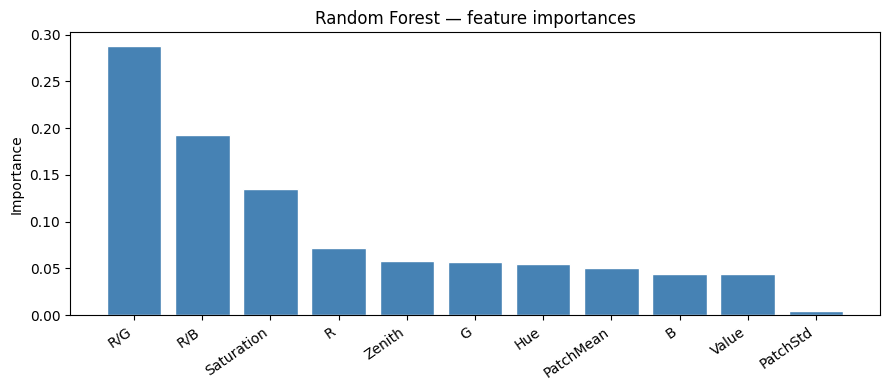

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced',  # handles sky/cloud imbalance
)
rf_model.fit(X_train_rf, y_train_rf)
print('Random Forest trained.')

# Feature importances
importances = rf_model.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(FEATURE_NAMES)),
       importances[sorted_idx], color='steelblue', edgecolor='white')
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels([FEATURE_NAMES[i] for i in sorted_idx], rotation=35, ha='right')
ax.set_ylabel('Importance')
ax.set_title('Random Forest — feature importances')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'rf_feature_importances.png', bbox_inches='tight', dpi=100)
plt.show()

### 3b. Evaluate Random Forest on Warsaw test set

In [11]:
def predict_rf(rf, img, dome_mask, zenith_weights, image_path=None):
    """Run Random Forest inference on a full image."""
    feats    = extract_features(img, zenith_weights)  # (H*W, 11)
    H, W     = img.shape[:2]
    flat_dom = dome_mask.ravel()
    pred_flat = np.zeros(H * W, dtype=np.uint8)
    pred_flat[flat_dom] = rf.predict(feats[flat_dom]).astype(np.uint8)
    pred_mask = pred_flat.reshape(H, W)
    from skycamera.sun import mask_sun_pixels
    active_mask = mask_sun_pixels(dome_mask, image_path) if image_path is not None else dome_mask
    cf_mask   = np.where(active_mask, pred_mask, np.uint8(255))
    cf        = weighted_cf(cf_mask, zenith_weights)
    return cf, pred_mask


if len(df_test) == 0:
    print('No test images.')
else:
    rf_gt, rf_pred, rf_iou = [], [], []
    for _, row in df_test.iterrows():
        img     = load_image(Path(row['image_path']))
        gt_mask = load_existing_mask(Path(row['mask_path']))
        gt_cf   = weighted_cf(gt_mask, zenith_weights)
        cf_pred, pred_mask = predict_rf(rf_model, img, dome_mask, zenith_weights)
        valid  = (gt_mask == LABEL_CLOUD) | (gt_mask == LABEL_SKY)
        gt_bin = (gt_mask == LABEL_CLOUD).astype(np.uint8)
        inter  = (pred_mask & gt_bin & valid).sum()
        union  = ((pred_mask | gt_bin) & valid).sum()
        rf_gt.append(gt_cf)
        rf_pred.append(cf_pred)
        rf_iou.append(inter / union if union > 0 else 0.0)

    rf_gt   = np.array(rf_gt)
    rf_pred = np.array(rf_pred)
    rf_iou  = np.array(rf_iou)
    ok_r    = ~np.isnan(rf_gt) & ~np.isnan(rf_pred)
    mae_r   = float(np.mean(np.abs(rf_pred[ok_r] - rf_gt[ok_r])))
    r_r     = float(np.corrcoef(rf_gt[ok_r], rf_pred[ok_r])[0,1]) if ok_r.sum() > 2 else float('nan')
    miou_r  = float(rf_iou.mean())
    print(f'Random Forest — Test set ({ok_r.sum()} images):')
    print(f'  MAE (CF)  : {mae_r:.4f}')
    print(f'  Pearson r : {r_r:.4f}')
    print(f'  Mean IoU  : {miou_r:.4f}')

Random Forest — Test set (126 images):
  MAE (CF)  : 0.1422
  Pearson r : 0.8269
  Mean IoU  : 0.3633


## 4. Comparison — all three models on Warsaw test set

ResNet-34 results loaded from `outputs/models/cnn_sky.pt` (notebook 03).
If that model does not exist yet, the ResNet-34 row is skipped.

In [12]:
from skycamera.cnn import load_cnn_model, predict_mask, IMG_SIZE

results = {}

# MobileNetV2
if len(df_test) > 0:
    results['MobileNetV2 U-Net'] = {
        'MAE': mae_m, 'r': r_m, 'IoU': miou_m,
        'gt': mobile_gt, 'pred': mobile_pred}
    results['Random Forest'] = {
        'MAE': mae_r, 'r': r_r, 'IoU': miou_r,
        'gt': rf_gt, 'pred': rf_pred}

# ResNet-34 (load from notebook 03 checkpoint)
RN34_PATH = MODEL_DIR / 'cnn_sky.pt'
if RN34_PATH.exists() and len(df_test) > 0:
    rn34_model = load_cnn_model(RN34_PATH)
    rn34_gt, rn34_pred, rn34_iou = [], [], []
    for _, row in df_test.iterrows():
        img     = load_image(Path(row['image_path']))
        gt_mask = load_existing_mask(Path(row['mask_path']))
        gt_cf   = weighted_cf(gt_mask, zenith_weights)
        cf_pred, pred_mask = predict_mask(
            rn34_model, img, dome_mask, IMG_SIZE, weights=zenith_weights)
        valid  = (gt_mask == LABEL_CLOUD) | (gt_mask == LABEL_SKY)
        gt_bin = (gt_mask == LABEL_CLOUD).astype(np.uint8)
        inter  = (pred_mask & gt_bin & valid).sum()
        union  = ((pred_mask | gt_bin) & valid).sum()
        rn34_gt.append(gt_cf)
        rn34_pred.append(cf_pred)
        rn34_iou.append(inter / union if union > 0 else 0.0)
    rn34_gt   = np.array(rn34_gt)
    rn34_pred = np.array(rn34_pred)
    ok_rn = ~np.isnan(rn34_gt) & ~np.isnan(rn34_pred)
    results['ResNet-34 U-Net'] = {
        'MAE':  float(np.mean(np.abs(rn34_pred[ok_rn]-rn34_gt[ok_rn]))),
        'r':    float(np.corrcoef(rn34_gt[ok_rn], rn34_pred[ok_rn])[0,1]),
        'IoU':  float(np.array(rn34_iou).mean()),
        'gt': rn34_gt, 'pred': rn34_pred}
else:
    print('ResNet-34 checkpoint not found — run notebook 03 first.')

# Summary table
rows = []
for name, m in results.items():
    rows.append({'Model': name, 'MAE': round(m['MAE'],4),
                 'Pearson r': round(m['r'],4), 'Mean IoU': round(m['IoU'],4)})
df_summary = pd.DataFrame(rows).set_index('Model')
print(df_summary.to_string())
df_summary.to_csv(CSV_DIR / 'model_comparison.csv')

                      MAE  Pearson r  Mean IoU
Model                                         
MobileNetV2 U-Net  0.0596     0.9514    0.4322
Random Forest      0.1422     0.8269    0.3633
ResNet-34 U-Net    0.0648     0.9494    0.4409


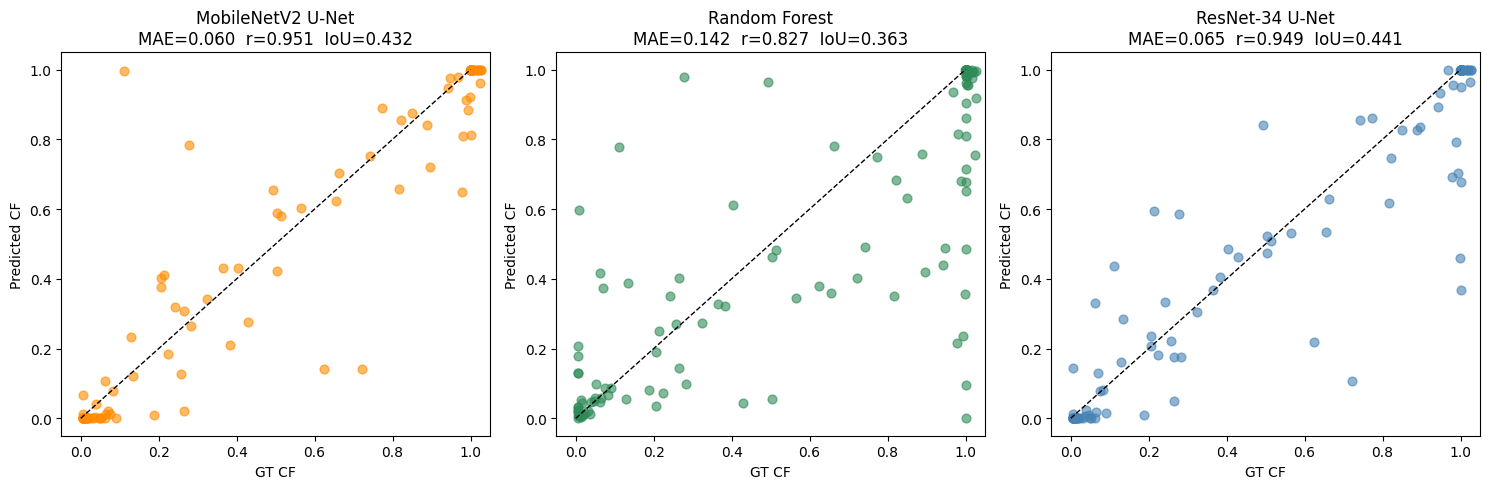

In [13]:
# Scatter plots — all models side by side
n = len(results)
if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1: axes = [axes]
    colours = {'MobileNetV2 U-Net': 'darkorange',
               'Random Forest': 'seagreen',
               'ResNet-34 U-Net': 'steelblue'}
    for ax, (name, m) in zip(axes, results.items()):
        gt, pred = m['gt'], m['pred']
        ok = ~np.isnan(gt) & ~np.isnan(pred)
        ax.scatter(gt[ok], pred[ok], alpha=0.6, s=40, color=colours.get(name, 'grey'))
        ax.plot([0,1],[0,1],'k--', linewidth=1)
        ax.set_xlabel('GT CF'); ax.set_ylabel('Predicted CF')
        ax.set_title(f'{name}\nMAE={m["MAE"]:.3f}  r={m["r"]:.3f}  IoU={m["IoU"]:.3f}')
        ax.set_xlim(-0.05,1.05); ax.set_ylim(-0.05,1.05)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / 'model_comparison_scatter.png', bbox_inches='tight', dpi=100)
    plt.show()

## 5. Qualitative comparison — sample predictions

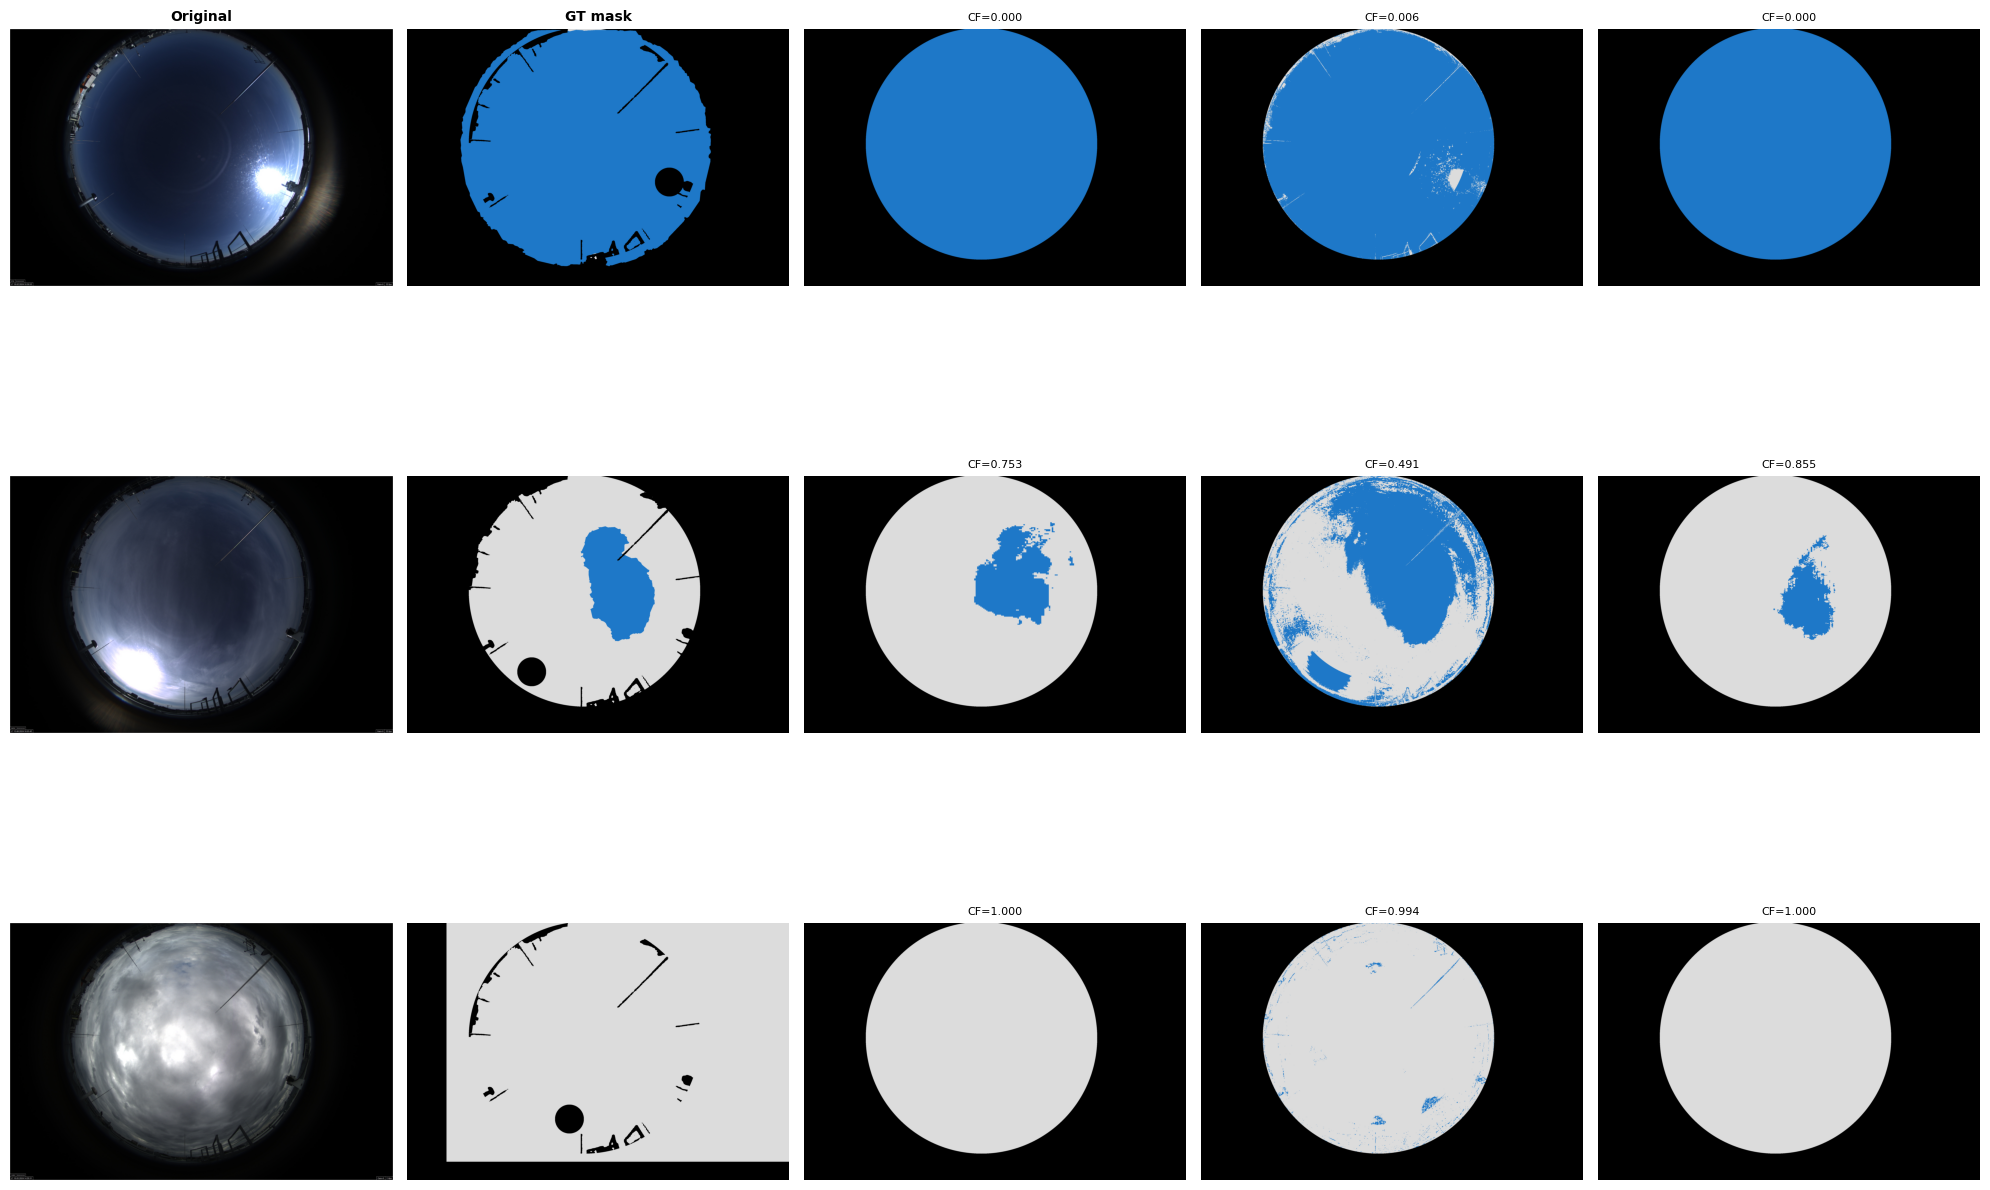

In [14]:
if len(df_test) == 0:
    print('No test images.')
else:
    df_test_sorted = df_test.sort_values('cf_measured').reset_index(drop=True)
    indices = np.linspace(0, len(df_test_sorted)-1, min(3, len(df_test_sorted)), dtype=int)
    samples = df_test_sorted.iloc[indices]

    n_models = 1 + (1 if 'MobileNetV2 U-Net' in results else 0) \
                 + (1 if 'Random Forest' in results else 0) \
                 + (1 if 'ResNet-34 U-Net' in results else 0)
    col_titles = ['Original', 'GT mask']
    if 'MobileNetV2 U-Net' in results: col_titles.append('MobileNetV2')
    if 'Random Forest'     in results: col_titles.append('Random Forest')
    if 'ResNet-34 U-Net'   in results: col_titles.append('ResNet-34')

    fig, axes = plt.subplots(len(samples), len(col_titles),
                             figsize=(4*len(col_titles), 5*len(samples)))
    if len(samples) == 1: axes = axes[np.newaxis,:]
    for ax, t in zip(axes[0], col_titles): ax.set_title(t, fontsize=10, fontweight='bold')

    for ri, (_, row) in enumerate(samples.iterrows()):
        img     = load_image(Path(row['image_path']))
        gt_mask = load_existing_mask(Path(row['mask_path']))
        gt_cf   = weighted_cf(gt_mask, zenith_weights)

        gt_vis = np.zeros((*gt_mask.shape, 3), dtype=np.uint8)
        gt_vis[gt_mask == LABEL_CLOUD] = [220, 220, 220]
        gt_vis[gt_mask == LABEL_SKY]   = [30, 120, 200]

        axes[ri][0].imshow(img)
        axes[ri][0].set_ylabel(f'GT CF={gt_cf:.2f}', fontsize=8)
        axes[ri][1].imshow(gt_vis)

        col = 2
        if 'MobileNetV2 U-Net' in results:
            cf_m, pm = predict_mask_generic(
                mobile_model, img, dome_mask, IMG_SIZE_MOBILE, zenith_weights,
                image_path=Path(row['image_path']))
            vis = np.zeros((*pm.shape,3), dtype=np.uint8)
            vis[pm==1]=[220,220,220]; vis[pm==0]=[30,120,200]; vis[~dome_mask]=0
            axes[ri][col].imshow(vis)
            axes[ri][col].set_title(f'CF={cf_m:.3f}', fontsize=8)
            col += 1
        if 'Random Forest' in results:
            cf_rf, prf = predict_rf(rf_model, img, dome_mask, zenith_weights,
                            image_path=Path(row['image_path']))
            vis = np.zeros((*prf.shape,3), dtype=np.uint8)
            vis[prf==1]=[220,220,220]; vis[prf==0]=[30,120,200]; vis[~dome_mask]=0
            axes[ri][col].imshow(vis)
            axes[ri][col].set_title(f'CF={cf_rf:.3f}', fontsize=8)
            col += 1
        if 'ResNet-34 U-Net' in results:
            cf_rn, prn = predict_mask(
                rn34_model, img, dome_mask, IMG_SIZE, weights=zenith_weights)
            vis = np.zeros((*prn.shape,3), dtype=np.uint8)
            vis[prn==1]=[220,220,220]; vis[prn==0]=[30,120,200]; vis[~dome_mask]=0
            axes[ri][col].imshow(vis)
            axes[ri][col].set_title(f'CF={cf_rn:.3f}', fontsize=8)

        for ax in axes[ri]: ax.axis('off')

    fig.tight_layout()
    fig.savefig(PLOTS_DIR / 'model_comparison_qualitative.png', bbox_inches='tight', dpi=100)
    plt.show()

## 6. Run best simpler model on all pilot images

Picks whichever of MobileNetV2 and RF has the lower MAE on the test set.
Results saved to `outputs/csv/cf_mobilenet.csv` or `outputs/csv/cf_rf.csv`.

In [15]:
if not results:
    print('No models evaluated — skipping.')
else:
    # Pick best simpler model by MAE
    simpler = {k: v for k, v in results.items() if k != 'ResNet-34 U-Net'}
    best_simple_name = min(simpler, key=lambda k: simpler[k]['MAE'])
    print(f'Best simpler model: {best_simple_name}  (MAE={simpler[best_simple_name]["MAE"]:.4f})')

    # Run on ALL images (day + night) — use shared index if available
    if INDEX_CSV.exists():
        df_index = pd.read_csv(INDEX_CSV, parse_dates=['timestamp'])
        df_index['path'] = df_index['path'].apply(Path)
    else:
        df_index = build_image_index(RAW_ROOT, apply_daytime_filter=False)

    out_rows = []
    for _, row in df_index.iterrows():
        try:
            img = load_image(row['path'])
            if best_simple_name == 'MobileNetV2 U-Net':
                cf, _ = predict_mask_generic(
                    mobile_model, img, dome_mask, IMG_SIZE_MOBILE, zenith_weights,
                    image_path=row['path'])
                csv_name = 'cf_mobilenet.csv'
            else:
                cf, _ = predict_rf(rf_model, img, dome_mask, zenith_weights,
                        image_path=row['path'])
                csv_name = 'cf_rf.csv'
            if not np.isnan(cf):
                out_rows.append({'timestamp': row['timestamp'],
                                 'cloud_fraction': round(cf, 4),
                                 'month': int(row['month']),
                                 'hour': int(row['hour']),
                                 'is_daytime': bool(row['is_daytime'])})
                if len(out_rows) % 24 == 0:
                    print(f'Number of processed images: {len(out_rows)}  | Date: {row["timestamp"].date()} |  Current CF={cf:.4f}')
        except Exception:
            continue

    df_out = pd.DataFrame(out_rows).sort_values('timestamp').reset_index(drop=True)
    df_out.to_csv(CSV_DIR / csv_name, index=False)
    print(f'Saved {len(df_out):,} rows -> {csv_name}')
    print(f'Daytime: {df_out["is_daytime"].sum():,}  Night: {(~df_out["is_daytime"]).sum():,}')
    print(f'Mean CF (all): {df_out["cloud_fraction"].mean():.3f}')
    print(f'Mean CF (daytime only): {df_out.loc[df_out["is_daytime"],"cloud_fraction"].mean():.3f}')
    df_out.head()

Best simpler model: MobileNetV2 U-Net  (MAE=0.0596)
Number of processed images: 24  | Date: 2024-01-02 |  Current CF=1.0000
Number of processed images: 48  | Date: 2024-01-02 |  Current CF=1.0000
Number of processed images: 72  | Date: 2024-01-03 |  Current CF=1.0000
Number of processed images: 96  | Date: 2024-01-03 |  Current CF=1.0000
Number of processed images: 120  | Date: 2024-01-04 |  Current CF=1.0000
Number of processed images: 144  | Date: 2024-01-04 |  Current CF=1.0000
Number of processed images: 168  | Date: 2024-01-05 |  Current CF=1.0000
Number of processed images: 192  | Date: 2024-01-05 |  Current CF=1.0000
Number of processed images: 216  | Date: 2024-01-06 |  Current CF=1.0000
Number of processed images: 240  | Date: 2024-01-06 |  Current CF=1.0000
Number of processed images: 264  | Date: 2024-01-07 |  Current CF=1.0000
Number of processed images: 288  | Date: 2024-01-07 |  Current CF=1.0000
Number of processed images: 312  | Date: 2024-01-08 |  Current CF=1.0000
Num